# Data-Driven Insights from Aadhaar Enrolment and Demographic Updates

## Problem Statement
UIDAI manages large-scale Aadhaar enrolment and update operations across India. 
However, identifying regional inefficiencies, abnormal update patterns, and enrolment gaps using aggregated data remains challenging.

This project analyses anonymised Aadhaar enrolment and demographic update datasets to:
- Identify temporal and regional patterns
- Detect anomalies in update behaviour
- Derive actionable insights to support operational decision-making


## Datasets Used

1. Aadhaar Enrolment Dataset  
   - Aggregated enrolments by date, state, district, pincode, and age group

2. Aadhaar Demographic Update Dataset  
   - Aggregated demographic updates by age group and geography

### Scope Decision
The Biometric Update dataset was not included as biometric updates are largely age-driven and expected, especially during childhood transitions. 
Analysing them without individual-level context may lead to misleading interpretations. 
Hence, this study focuses on datasets with clearer operational and policy relevance.


## Data Loading and Consolidation
Multiple CSV files were provided for each dataset. These were merged to form unified datasets.


In [2]:
import pandas as pd
from glob import glob


In [3]:
enrolment_files = glob(
    r"api_data_aadhar_enrolment/**/*.csv",
    recursive=True
)

print("Enrolment files found:", len(enrolment_files))
enrolment_files


Enrolment files found: 3


['api_data_aadhar_enrolment\\api_data_aadhar_enrolment_0_500000.csv',
 'api_data_aadhar_enrolment\\api_data_aadhar_enrolment_1000000_1006029.csv',
 'api_data_aadhar_enrolment\\api_data_aadhar_enrolment_500000_1000000.csv']

In [7]:
demo_files = glob(
    r"api_data_aadhar_demographic/**/*.csv",
    recursive=True
)

print("Demographic files found:", len(demo_files))
demo_files


Demographic files found: 5


['api_data_aadhar_demographic\\api_data_aadhar_demographic_0_500000.csv',
 'api_data_aadhar_demographic\\api_data_aadhar_demographic_1000000_1500000.csv',
 'api_data_aadhar_demographic\\api_data_aadhar_demographic_1500000_2000000.csv',
 'api_data_aadhar_demographic\\api_data_aadhar_demographic_2000000_2071700.csv',
 'api_data_aadhar_demographic\\api_data_aadhar_demographic_500000_1000000.csv']

In [5]:
enrolment_df = pd.concat(
    [pd.read_csv(f) for f in enrolment_files],
    ignore_index=True
)

print("Enrolment dataset shape:", enrolment_df.shape)
enrolment_df.head()



Enrolment dataset shape: (1006029, 7)


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21


In [8]:
demo_df = pd.concat(
    [pd.read_csv(f) for f in demo_files],
    ignore_index=True
)

print("Demographic dataset shape:", demo_df.shape)
demo_df.head()


Demographic dataset shape: (2071700, 6)


,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,01-03-2025,Uttar Pradesh,Gorakhpur,273213,49,529
1,01-03-2025,Andhra Pradesh,Chittoor,517132,22,375
2,01-03-2025,Gujarat,Rajkot,360006,65,765
3,01-03-2025,Andhra Pradesh,Srikakulam,532484,24,314
4,01-03-2025,Rajasthan,Udaipur,313801,45,785


# Rename enrolment columns for clarity and consistency

In [10]:
enrolment_df.rename(columns={
    "age_0_5": "enrol_age_0_5",
    "age_5_17": "enrol_age_5_17",
    "age_18_greater": "enrol_age_18_plus"
}, inplace=True)

# Verify column names
enrolment_df.columns


Index(['date', 'state', 'district', 'pincode', 'enrol_age_0_5',
       'enrol_age_5_17', 'enrol_age_18_plus'],
      dtype='object')

# Rename demographic update columns for clarity

In [9]:
demo_df.rename(columns={
    "demo_age_5_17": "demo_updates_5_17",
    "demo_age_17_": "demo_updates_18_plus"
}, inplace=True)

# Verify column names
demo_df.columns


Index(['date', 'state', 'district', 'pincode', 'demo_updates_5_17',
       'demo_updates_18_plus'],
      dtype='object')

# Convert date column to datetime for both datasets
# Verify data types

In [11]:
enrolment_df["date"] = pd.to_datetime(enrolment_df["date"], format="%d-%m-%Y")
demo_df["date"] = pd.to_datetime(demo_df["date"], format="%d-%m-%Y")

enrolment_df.dtypes, demo_df.dtypes


(date                 datetime64[ns]
 state                        object
 district                     object
 pincode                       int64
 enrol_age_0_5                 int64
 enrol_age_5_17                int64
 enrol_age_18_plus             int64
 dtype: object,
 date                    datetime64[ns]
 state                           object
 district                        object
 pincode                          int64
 demo_updates_5_17                int64
 demo_updates_18_plus             int64
 dtype: object)

## Merging Enrolment and Demographic Update Data

After cleaning and standardizing both datasets, the enrolment and demographic
update data are merged to create a unified analytical dataset.

The merge is performed using common temporal and geographic keys:
- Date
- State
- District
- Pincode

An **inner join** is used to ensure that only records present in both datasets
are included. This avoids misalignment and ensures reliable analysis.


In [12]:
merged_df = pd.merge(
    enrolment_df,
    demo_df,
    on=["date", "state", "district", "pincode"],
    how="inner"
)

print("Merged dataset shape:", merged_df.shape)
merged_df.head()


Merged dataset shape: (861171, 9)


,date,state,district,pincode,enrol_age_0_5,enrol_age_5_17,enrol_age_18_plus,demo_updates_5_17,demo_updates_18_plus
0,2025-04-01,Punjab,Ludhiana,141007,374,110,25,206,2000
1,2025-04-01,Punjab,Ludhiana,141007,374,110,25,206,2000
2,2025-04-01,Madhya Pradesh,Ashok Nagar,473335,125,29,22,181,975
3,2025-04-01,Madhya Pradesh,Ashok Nagar,473335,125,29,22,181,975
4,2025-04-01,Jharkhand,Ranchi,834001,187,174,21,210,1855


### Aggregating Enrolment Data

Before merging, enrolment data is aggregated at the
(date, state, district, pincode) level to avoid duplicate records.


In [13]:
enrolment_agg = enrolment_df.groupby(
    ["date", "state", "district", "pincode"],
    as_index=False
).sum()

enrolment_agg.head()


,date,state,district,pincode,enrol_age_0_5,enrol_age_5_17,enrol_age_18_plus
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37
1,2025-03-09,Bihar,Bhagalpur,812005,13,40,18
2,2025-03-09,Bihar,Madhubani,847108,18,120,22
3,2025-03-09,Bihar,Purbi Champaran,845304,18,72,12
4,2025-03-09,Bihar,Purbi Champaran,845418,30,48,10


### Aggregating Demographic Update Data

Similar to enrolment data, demographic update data is aggregated at the
(date, state, district, pincode) level.  
This ensures a one-to-one relationship between records before merging
both datasets.


In [14]:
demo_agg = demo_df.groupby(
    ["date", "state", "district", "pincode"],
    as_index=False
).sum()

demo_agg.head()


,date,state,district,pincode,demo_updates_5_17,demo_updates_18_plus
0,2025-03-01,Andaman and Nicobar Islands,Nicobar,744301,32,360
1,2025-03-01,Andaman and Nicobar Islands,North And Middle Andaman,744202,20,402
2,2025-03-01,Andaman and Nicobar Islands,South Andaman,744101,13,76
3,2025-03-01,Andaman and Nicobar Islands,South Andaman,744103,25,161
4,2025-03-01,Andaman and Nicobar Islands,South Andaman,744105,26,171


### Final Merging of Aggregated Datasets

After aggregating both the enrolment and demographic update datasets at the
same geographic and temporal level, the two datasets are merged.

This ensures:
- One record per (date, state, district, pincode)
- No duplicate rows
- Accurate and interpretable analysis


In [15]:
merged_df = pd.merge(
    enrolment_agg,
    demo_agg,
    on=["date", "state", "district", "pincode"],
    how="inner"
)

print("Final merged dataset shape:", merged_df.shape)
merged_df.head()


Final merged dataset shape: (651714, 9)


,date,state,district,pincode,enrol_age_0_5,enrol_age_5_17,enrol_age_18_plus,demo_updates_5_17,demo_updates_18_plus
0,2025-04-01,Assam,Bongaigaon,783380,74,29,27,182,2488
1,2025-04-01,Assam,Bongaigaon,783384,135,47,21,166,1519
2,2025-04-01,Bihar,Bhagalpur,812005,329,296,16,930,4372
3,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441
4,2025-04-01,Chhattisgarh,Durg,491001,336,38,10,902,4150


## Feature Engineering

To derive meaningful insights, additional features are created from the
merged dataset. These features help in comparing enrolment activity with
demographic update behaviour.

The following metrics are derived:
- Total Enrolments
- Total Demographic Updates
- Update-to-Enrolment Ratio


In [16]:
# Total enrolments across all age groups
merged_df["total_enrolments"] = (
    merged_df["enrol_age_0_5"] +
    merged_df["enrol_age_5_17"] +
    merged_df["enrol_age_18_plus"]
)

# Total demographic updates across age groups
merged_df["total_demo_updates"] = (
    merged_df["demo_updates_5_17"] +
    merged_df["demo_updates_18_plus"]
)

# Update-to-Enrolment Ratio
merged_df["update_enrolment_ratio"] = (
    merged_df["total_demo_updates"] /
    (merged_df["total_enrolments"] + 1)  # +1 to avoid division by zero
)

merged_df.head()


,date,state,district,pincode,enrol_age_0_5,enrol_age_5_17,enrol_age_18_plus,demo_updates_5_17,demo_updates_18_plus,total_enrolments,total_demo_updates,update_enrolment_ratio
0,2025-04-01,Assam,Bongaigaon,783380,74,29,27,182,2488,130,2670,20.381679
1,2025-04-01,Assam,Bongaigaon,783384,135,47,21,166,1519,203,1685,8.259804
2,2025-04-01,Bihar,Bhagalpur,812005,329,296,16,930,4372,641,5302,8.258567
3,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,117,1841,15.601695
4,2025-04-01,Chhattisgarh,Durg,491001,336,38,10,902,4150,384,5052,13.122078


## State-wise Comparison of Update-to-Enrolment Ratio

To understand regional differences, the update-to-enrolment ratio is
aggregated at the state level.

This analysis highlights states where demographic updates are relatively
high compared to new enrolments, which may indicate:
- Operational inefficiencies
- Repeated data corrections
- Awareness or process-related issues


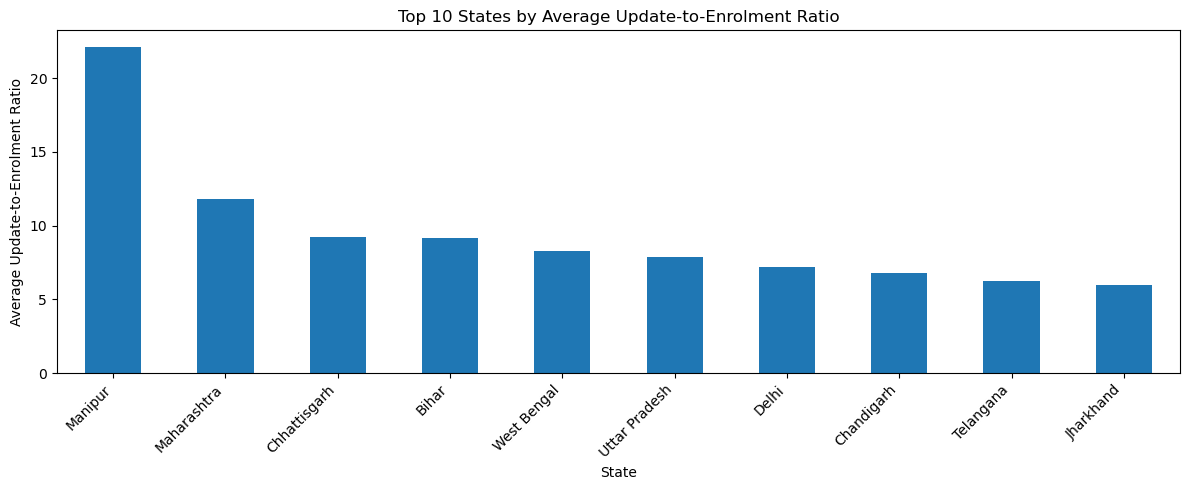

In [17]:
import matplotlib.pyplot as plt

# Calculate average ratio per state
state_ratio = (
    merged_df
    .groupby("state")["update_enrolment_ratio"]
    .mean()
    .sort_values(ascending=False)
)

# Plot top 10 states
state_ratio.head(10).plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Top 10 States by Average Update-to-Enrolment Ratio")
plt.xlabel("State")
plt.ylabel("Average Update-to-Enrolment Ratio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Anomaly Detection in Update-to-Enrolment Ratio

To identify states with unusually high update-to-enrolment ratios,
a statistical anomaly detection approach is applied.

Z-score is used to measure how far a state's average ratio deviates
from the national mean. States with a Z-score greater than 3 are
considered statistically significant outliers.

This helps in distinguishing genuinely abnormal patterns from
normal regional variation.


In [18]:
from scipy.stats import zscore

# Create a DataFrame for state-level ratios
state_ratio_df = state_ratio.reset_index()
state_ratio_df.columns = ["state", "avg_update_enrolment_ratio"]

# Calculate Z-score
state_ratio_df["z_score"] = zscore(state_ratio_df["avg_update_enrolment_ratio"])

# Identify anomalies
anomalous_states = state_ratio_df[state_ratio_df["z_score"] > 3]

state_ratio_df.sort_values("z_score", ascending=False).head(10)


,state,avg_update_enrolment_ratio,z_score
0,Manipur,22.148547,5.010489
1,Maharashtra,11.792391,2.073258
2,Chhattisgarh,9.198247,1.337502
3,Bihar,9.144124,1.322151
4,West Bengal,8.285426,1.078606
5,Uttar Pradesh,7.898373,0.968830
6,Delhi,7.166482,0.761249
7,Chandigarh,6.790667,0.654660
8,Telangana,6.212322,0.490629
9,Jharkhand,5.964104,0.420229


## District-Level Analysis for Anomalous States

State-level analysis identified Manipur as a statistically significant
outlier with an unusually high update-to-enrolment ratio.

To support targeted decision-making, a district-level drill-down is
performed for this anomalous state. This helps identify specific districts
contributing to the elevated state-level ratio.


In [19]:
# Identify anomalous states (z-score > 3)
anomalous_state_list = anomalous_states["state"].tolist()

anomalous_state_list


['Manipur']

In [20]:
# Filter merged data for anomalous state(s)
district_df = merged_df[
    merged_df["state"].isin(anomalous_state_list)
]

# Calculate district-level average ratio
district_ratio = (
    district_df
    .groupby(["state", "district"])["update_enrolment_ratio"]
    .mean()
    .sort_values(ascending=False)
)

district_ratio.head(10)


state    district     
Manipur  Bishnupur        49.261790
         Thoubal          47.213837
         Imphal East      30.829803
         Imphal West      29.219291
         Kakching         13.927519
         Ukhrul           12.800837
         Chandel          10.115845
         Senapati          8.790489
         Churachandpur     7.285584
         Tamenglong        7.049359
Name: update_enrolment_ratio, dtype: float64

## Key Insights

### 1. Manipur Identified as a Statistical Outlier
State-level anomaly detection using Z-score identified **Manipur** as a
statistically significant outlier with an exceptionally high
update-to-enrolment ratio (Z-score ≈ 5).

This indicates that demographic updates in Manipur are disproportionately
high compared to new Aadhaar enrolments.

---

### 2. High Concentration of Updates in Specific Districts
District-level drill-down within Manipur reveals that the elevated
state-level ratio is driven by a small number of districts:

- Bishnupur
- Thoubal
- Imphal East
- Imphal West

These districts show update-to-enrolment ratios significantly higher than
both the state and national averages.

---

### 3. Pattern Suggests Operational or Process-Level Factors
The concentration of high ratios in specific districts suggests that the
issue is **localized rather than statewide**, indicating potential:
- Data quality issues during initial enrolment
- Repeated demographic corrections
- Process inefficiencies or awareness gaps

No conclusions regarding misuse are drawn, as the data is aggregated and
anonymised.

---

## Recommendations

### 1. Targeted Operational Review
UIDAI may consider conducting focused operational reviews or audits in
high-ratio districts such as Bishnupur and Thoubal to identify root causes.

---

### 2. Improve Enrolment Data Quality
Strengthening validation checks and operator training during enrolment
can reduce the need for repeated demographic updates.

---

### 3. Use Ratio as an Early Warning Indicator
The update-to-enrolment ratio can be adopted as a **monitoring metric**
to proactively identify regions requiring attention before issues escalate.

---

### 4. District-Level Monitoring Dashboards
Implementing dashboards at the district level would enable continuous,
data-driven monitoring of enrolment and update patterns across regions.

---

## Limitations

- Analysis is based on aggregated, anonymised data
- Individual-level validation is not possible
- Findings indicate patterns, not causation
